Load data

In [1]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/inst/extdata/penguins.csv")

In [2]:
print(df.shape)                # (344, 8)
print(df.info())               # types + missing counts
print(df.head())
print(df.tail())
print(df.describe(include='all'))   # good overview

(344, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 21.6+ KB
None
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN       

Target has 3 classes: Adelie, Gentoo, Chinstrap
Features: 
    - Numerical: bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g
    - Categorical: island, sex
    - Metadata / not useful for prediction: year (usually drop it), rowid if present (drop)
Handle missing values:
    -   drop the few rows with missing values
    - impute the mode value to the missing ones


preprocessing / EDA pipeline
(before starting to model)

In [3]:
df = df.dropna()

# Numerical: median (robust to outliers)
for col in ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']:
    df[col] = df[col].fillna(df[col].median())

# Categorical: mode
df['sex'] = df['sex'].fillna(df['sex'].mode()[0])

print(df)

       species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0       Adelie  Torgersen            39.1           18.7              181.0   
1       Adelie  Torgersen            39.5           17.4              186.0   
2       Adelie  Torgersen            40.3           18.0              195.0   
4       Adelie  Torgersen            36.7           19.3              193.0   
5       Adelie  Torgersen            39.3           20.6              190.0   
..         ...        ...             ...            ...                ...   
339  Chinstrap      Dream            55.8           19.8              207.0   
340  Chinstrap      Dream            43.5           18.1              202.0   
341  Chinstrap      Dream            49.6           18.2              193.0   
342  Chinstrap      Dream            50.8           19.0              210.0   
343  Chinstrap      Dream            50.2           18.7              198.0   

     body_mass_g     sex  year  
0         3750.0  

Encode categorical variables
    -  OrdinalEncoder or LabelEncoder (simple & fine for trees)
    -  One-hot encoding (also works, but trees don't need it — creates more columns)

In [37]:
from sklearn.preprocessing import LabelEncoder

le_species = LabelEncoder()
le_island  = LabelEncoder()
le_sex     = LabelEncoder()

df['species_encoded'] = le_species.fit_transform(df['species'])
df['island_encoded']  = le_island.fit_transform(df['island'])
df['sex_encoded']     = le_sex.fit_transform(df['sex'])

df = df.drop('species',axis=1)
df = df.drop('island',axis=1)
df = df.drop('sex',axis=1)

Exploratory Data Analysis

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pairplot – shows separations very clearly (classic for penguins!)
sns.pairplot(df, hue='species', palette='husl')
plt.show()

# Boxplots per feature
for col in ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']:
    sns.boxplot(data=df, x='species', y=col)
    plt.show()

flipper_length + bill_length/depth separate the species very well → decision tree will probably do great.

In [21]:
# Drop columns you don't want (usually year)
df = df.drop(columns=['year'], errors='ignore')

# X / y split
X = df.drop('species', axis=1)
y = df['species']

# Train-test split (do this after preprocessing!)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X)
print(y)

     island  bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
0         2            39.1           18.7              181.0       3750.0   
1         2            39.5           17.4              186.0       3800.0   
2         2            40.3           18.0              195.0       3250.0   
4         2            36.7           19.3              193.0       3450.0   
5         2            39.3           20.6              190.0       3650.0   
..      ...             ...            ...                ...          ...   
339       1            55.8           19.8              207.0       4000.0   
340       1            43.5           18.1              202.0       3400.0   
341       1            49.6           18.2              193.0       3775.0   
342       1            50.8           19.0              210.0       4100.0   
343       1            50.2           18.7              198.0       3775.0   

     sex  species_encoded  island_encoded  sex_encoded  
0     

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

tree = DecisionTreeClassifier(
    max_depth=1,            # keep small → very interpretable
    min_samples_leaf=5,     # prevent overfitting on tiny leaves
    random_state=42
)

tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=1, min_samples_leaf=5, random_state=42)

In [44]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_pred = tree.predict(X_test)
print(y_pred)
print(y_test)

acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {acc:.4f} ({acc*100:.2f}%)")

print("\nClassification Report:")
# print(classification_report(y_test, y_pred, target_names=le_species.classes_))

[2 2 0 2 2 2 2 0 0 2 2 0 0 2 2 0 2 0 2 2 2 2 0 2 2 0 0 0 2 2 2 0 0 0 0 0 2
 2 0 0 0 2 2 2 2 0 2 2 2 2 2 0 2 0 2 0 0 2 0 2 0 2 2 0 2 0 0]
262    2
338    1
93     0
240    2
222    2
      ..
196    2
122    0
207    2
98     0
65     0
Name: species, Length: 67, dtype: int32

Accuracy: 0.7910 (79.10%)

Classification Report:


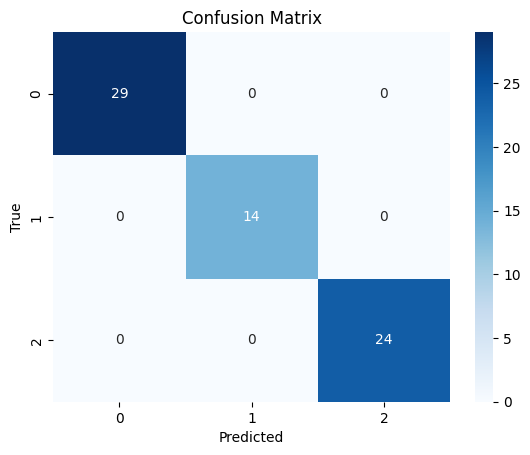

In [41]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_species.classes_,
            yticklabels=le_species.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


Feature Importances:
             Feature  Importance
6    species_encoded         1.0
0             island         0.0
1     bill_length_mm         0.0
2      bill_depth_mm         0.0
3  flipper_length_mm         0.0
4        body_mass_g         0.0
5                sex         0.0
7     island_encoded         0.0
8        sex_encoded         0.0


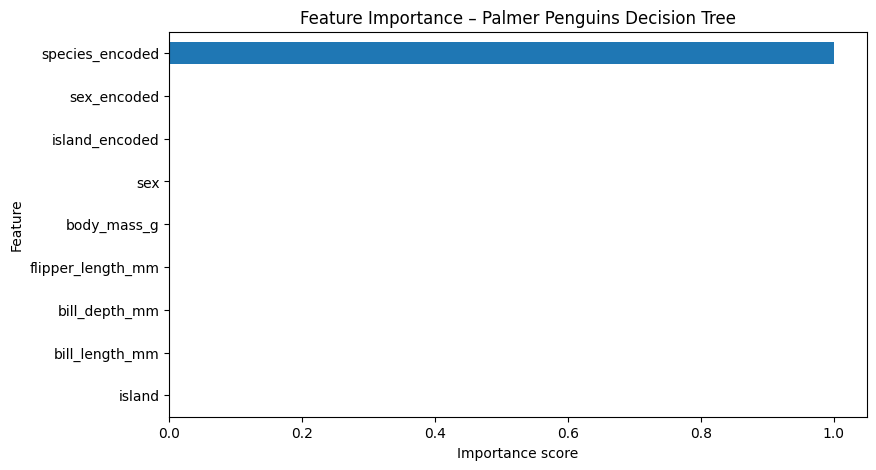

In [45]:
import pandas as pd

features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g',
            'island_encoded', 'sex_encoded']

# Feature importances
importances = tree.feature_importances_
features = tree.feature_names_in_

fi_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values('Importance', ascending=False).round(4)

print("\nFeature Importances:")
print(fi_df)

# Optional: horizontal bar plot (very readable)
fi_df.set_index('Feature')['Importance'].sort_values().plot(kind='barh', figsize=(9, 5))
plt.title('Feature Importance – Palmer Penguins Decision Tree')
plt.xlabel('Importance score')
plt.show()

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 10))           # make it large enough
plot_tree(
    tree,
    feature_names=features,
    class_names=le_species.classes_,
    filled=True,
    rounded=True,
    fontsize=10,
    impurity=False,
    proportion=False,
    node_ids=True,                     # optional: shows node numbers
    precision=2
)
plt.title("Decision Tree – Palmer Penguins Species Classification", fontsize=16)
plt.tight_layout()

# Save to file
plt.savefig("penguins_decision_tree.png", dpi=300, bbox_inches='tight')   # high quality
# plt.savefig("penguins_tree.pdf", bbox_inches='tight')                   # vector format
plt.show()

In [51]:
from sklearn.ensemble import RandomForestClassifier   # ← new import

rf = RandomForestClassifier(
    n_estimators=100,       # number of trees – default 100 is fine
    max_depth=1,            # limit depth to prevent overfit (optional)
    min_samples_leaf=2,     # prevent tiny leaves
    random_state=42,
    n_jobs=-1               # use all CPU cores for speed
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=1, min_samples_leaf=2, n_jobs=-1,
                       random_state=42)

In [57]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=100,       # number of boosting stages / trees
    learning_rate=0.1,      # step size – smaller = slower but often better
    max_depth=1,            # depth of each tree – keep shallow
    min_samples_leaf=2,     # prevent overfitting
    random_state=42
)

gb.fit(X_train, y_train)


GradientBoostingClassifier(max_depth=1, min_samples_leaf=2, random_state=42)

In [61]:
from xgboost import XGBClassifier   # pip install xgboost if needed

# ────────────────────────────────────────────────
# 5. Train XGBoost Classifier
# ────────────────────────────────────────────────
xgb = XGBClassifier(
    n_estimators=100,       # number of boosting rounds
    learning_rate=0.1,      # step size
    max_depth=3,            # depth of each tree
    min_child_weight=5,     # similar to min_samples_leaf
    random_state=42,
    n_jobs=-1,              # use all cores
    use_label_encoder=False, # avoid warnings
    eval_metric='mlogloss'  # for multi-class
)

xgb.fit(X_train, y_train)

c:\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:58:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1,
              num_parallel_tree=None, ...)

In [62]:
from lightgbm import LGBMClassifier
lgbm = LGBMClassifier(
    n_estimators=100,       # number of boosting rounds
    learning_rate=0.1,      # step size
    max_depth=3,            # depth of each tree
    min_child_samples=5,    # similar to min_samples_leaf
    random_state=42,
    n_jobs=-1,              # use all cores
    verbose=-1              # suppress output
)

lgbm.fit(X_train, y_train)

LGBMClassifier(max_depth=3, min_child_samples=5, n_jobs=-1, random_state=42,
               verbose=-1)

In [63]:
y_pred_rf = rf.predict(X_test)
y_pred_gb = gb.predict(X_test)
y_pred_lgbm = lgbm.predict(X_test)
y_pred_xgb = lgbm.predict(X_test)

print(y_pred_rf)
print(y_pred_gb)
print(y_pred_lgbm)
print(y_pred_xgb)
print(y_pred)

acc = accuracy_score(y_test, y_pred)
acc_rf = accuracy_score(y_test, y_pred_rf)
acc_gb = accuracy_score(y_test, y_pred_gb)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
acc_lgbm = accuracy_score(y_test, y_pred_gb)

print(f"\nAccuracy dec tree: {acc:.4f} ({acc*100:.2f}%)")   # usually 0.9880–1.0000
print(f"\nAccuracy random forest: {acc_rf:.4f} ({acc_rf*100:.2f}%)")   # usually 0.9880–1.0000
print(f"\nAccuracy grad boost: {acc_gb:.4f} ({acc_gb*100:.2f}%)")   # usually 0.9880–1.0000
print(f"\nAccuracy lgbm: {acc_lgbm:.4f} ({acc_lgbm*100:.2f}%)")   # usually 0.9880–1.0000
print(f"\nAccuracy xgb: {acc_xgb:.4f} ({acc_xgb*100:.2f}%)")   # usually 0.9880–1.0000


[2 0 0 2 2 2 0 0 0 2 0 0 0 0 0 0 0 0 0 2 0 2 0 2 2 0 0 0 2 0 2 0 0 0 0 0 2
 2 0 0 0 2 2 2 0 0 2 2 2 0 2 0 2 0 2 0 0 0 0 2 0 2 2 0 2 0 0]
[2 1 0 2 2 2 1 0 0 2 1 0 0 1 1 0 1 0 1 2 1 2 0 2 2 0 0 0 2 1 2 0 0 0 0 0 2
 2 0 0 0 2 2 2 1 0 2 1 2 1 2 0 1 0 2 0 0 1 0 2 0 2 2 0 2 0 0]
[2 1 0 2 2 2 1 0 0 2 1 0 0 1 1 0 1 0 1 2 1 2 0 2 2 0 0 0 2 1 2 0 0 0 0 0 2
 2 0 0 0 2 2 2 1 0 2 1 2 1 2 0 1 0 2 0 0 1 0 2 0 2 2 0 2 0 0]
[2 1 0 2 2 2 1 0 0 2 1 0 0 1 1 0 1 0 1 2 1 2 0 2 2 0 0 0 2 1 2 0 0 0 0 0 2
 2 0 0 0 2 2 2 1 0 2 1 2 1 2 0 1 0 2 0 0 1 0 2 0 2 2 0 2 0 0]
[2 1 0 2 2 2 1 0 0 2 1 0 0 1 1 0 1 0 1 2 1 2 0 2 2 0 0 0 2 1 2 0 0 0 0 0 2
 2 0 0 0 2 2 2 1 0 2 1 2 1 2 0 1 0 2 0 0 1 0 2 0 2 2 0 2 0 0]

Accuracy dec tree: 1.0000 (100.00%)

Accuracy random forest: 0.7910 (79.10%)

Accuracy grad boost: 1.0000 (100.00%)

Accuracy lgbm: 1.0000 (100.00%)

Accuracy xgb: 1.0000 (100.00%)


pruning / cost-complexity / cross-validation next